# Malaria Classification Task (Infected or UnInfected)

<p> Colored Picture usually have 3 channels - Red, Blue and Green. Each pixel is made of a combination of these 3 channels. 
So our tensor for a colored picture will be (H,W,3): 3 is for 3 channels. A gray scale image has only 1 channel, therefore we have (H,W,1)</p>


<p>(Black = 0) --- (White = 255)</p>
<p>After Normalization, (Black = 0) --- (White = 1)</p>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf # type: ignore
import tensorflow_datasets as tfds # type: ignore

# MODELS
Model = tf.keras.Model

#LAYERS
Input = tf.keras.layers.Input
Normalization = tf.keras.layers.Normalization

Dense = tf.keras.layers.Dense
InputLayer = tf.keras.layers.InputLayer
Conv2D = tf.keras.layers.Conv2D
MaxPool2D = tf.keras.layers.MaxPool2D
Flatten = tf.keras.layers.Flatten # Flatten is a function so you don't need a parantheses at the end.
BatchNormalization = tf.keras.layers.BatchNormalization
Layer = tf.keras.layers.Layer


#LOSSES
bce = tf.keras.losses.BinaryCrossentropy() # To instantiate a class you need to build an object which can only be done by including a parantheses at the end. 

# OPTIMIZER
Adam = tf.keras.optimizers.Adam

In [2]:
dataset, dataset_info = tfds.load('malaria', with_info=True, as_supervised = True, shuffle_files=True, split=['train']) # tfds_load returns the dataset and dataset_info | 'with_info=True' gives the dataset_info
# as_supervised -> if True returns a dataset with a 2 tuple structure (input, label)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/malaria/incomplete.BGURL9_1.0.0/malaria-train.tfrecord*...:   0%|         …

Dataset malaria downloaded and prepared to /root/tensorflow_datasets/malaria/1.0.0. Subsequent calls will reuse this data.


In [3]:
dataset # this is a list with 1 element, so only select dataset[0]

[<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>]

In [4]:
dataset_info

tfds.core.DatasetInfo(
    name='malaria',
    full_name='malaria/1.0.0',
    description="""
    The Malaria dataset contains a total of 27,558 cell images with equal instances
    of parasitized and uninfected cells from the thin blood smear slide images of
    segmented cells.
    """,
    homepage='https://lhncbc.nlm.nih.gov/publication/pub9932',
    data_dir='/root/tensorflow_datasets/malaria/1.0.0',
    file_format=tfrecord,
    download_size=337.08 MiB,
    dataset_size=317.62 MiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=27558, num_shards=4>,
    },
    citation="""@article{rajaraman2018pre,
      title={Pre-trained convolutional neural networks as feature extractors toward
      improved malaria parasit

In [5]:
for data in dataset[0].take(2):
    print(data)

(<tf.Tensor: shape=(145, 148, 3), dtype=uint8, numpy=
array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)>, <tf.Tensor: shape=(), dtype=int64, numpy=1>)
(<tf.Tensor: shape=(133, 127, 3), dtype=uint8, numpy=
array([[[0, 0, 0],
        [0, 0, 0],
       

### Creating the Train, Test, Validation Datasets

In [6]:
def splits(dataset, TRAIN_RATIO, VAL_RATIO, TEST_RATIO):
    DATASET_SIZE = len(dataset)

    train_dataset =  dataset.take(int(TRAIN_RATIO * DATASET_SIZE)) # TRAINING DATASET

    val_test_dataset = dataset.skip(int(TRAIN_RATIO * DATASET_SIZE))

    val_dataset = val_test_dataset.take(int(VAL_RATIO*DATASET_SIZE)) # VALIDATION DATASET
    test_dataset = val_test_dataset.skip(int(TEST_RATIO * DATASET_SIZE)) # TEST DATASET

    return train_dataset, val_dataset, test_dataset



In [7]:
TRAIN_RATIO = 0.6
VAL_RATIO = 0.2
TEST_RATIO = 0.2

# dataset = tf.data.Dataset.range(10)

train_dataset, val_dataset, test_dataset = splits(dataset[0], TRAIN_RATIO, VAL_RATIO, TEST_RATIO)


print('Train Dataset\n', list(train_dataset.take(1).as_numpy_iterator()),'Val Dataset\n', list(val_dataset.take(1).as_numpy_iterator()),'Test Dataset\n', list(test_dataset.take(1).as_numpy_iterator()))

Train Dataset
 [(array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8), np.int64(0))] Val Dataset
 [(array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
     

In [8]:
for image, label in train_dataset.take(16):
    print("Image Matrix Shape:", image.shape) 
    print("Label Value:", label.numpy())

Image Matrix Shape: (145, 148, 3)
Label Value: 1
Image Matrix Shape: (133, 127, 3)
Label Value: 1
Image Matrix Shape: (118, 118, 3)
Label Value: 0
Image Matrix Shape: (124, 121, 3)
Label Value: 1
Image Matrix Shape: (151, 148, 3)
Label Value: 0
Image Matrix Shape: (151, 130, 3)
Label Value: 0
Image Matrix Shape: (139, 175, 3)
Label Value: 1
Image Matrix Shape: (151, 139, 3)
Label Value: 0
Image Matrix Shape: (160, 148, 3)
Label Value: 0
Image Matrix Shape: (124, 130, 3)
Label Value: 1
Image Matrix Shape: (133, 136, 3)
Label Value: 1
Image Matrix Shape: (145, 163, 3)
Label Value: 0
Image Matrix Shape: (112, 115, 3)
Label Value: 0
Image Matrix Shape: (133, 133, 3)
Label Value: 0
Image Matrix Shape: (166, 184, 3)
Label Value: 0
Image Matrix Shape: (136, 130, 3)
Label Value: 1


# Data Visualization

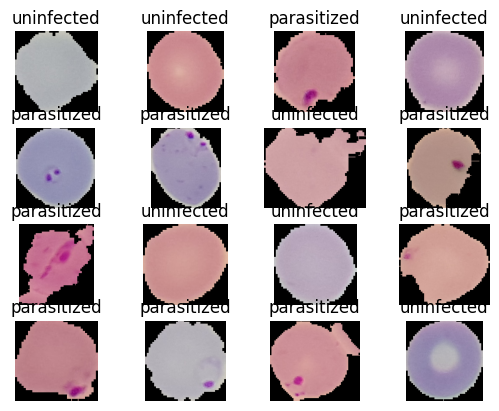

In [9]:
for i, (image, label) in enumerate(train_dataset.take(16)): # when using .take(), it goes fomr 1 - 16, hence the 'i+1'
    ax = plt.subplot(4,4, i+1) #(4,4) because we have 16 images
    plt.imshow(image)
    plt.title(dataset_info.features['label'].int2str(label))
    plt.axis('off')

In [10]:
dataset_info.features['label'].int2str(0) # our label of 0 means that it is parasitized

'parasitized'

In [11]:
dataset_info.features['label'].int2str(1) # our label of 1 means that it is uninfected

'uninfected'

# Data Pre - Processing

##### Image Resizing -> Converting each image to 224,224 resolution

##### Standardization or Normalization

In [12]:
IM_SIZE = 224
def resize_rescale(image, label):
    return tf.image.resize(image,(IM_SIZE, IM_SIZE))/255.0, label
# We are dividing by 255 to rescale

In [13]:
train_dataset = train_dataset.map(resize_rescale)
val_dataset = val_dataset.map(resize_rescale)
test_dataset = test_dataset.map(resize_rescale)


In [14]:
for image, label in train_dataset.take(1):
    print(image, label)
# Image is resized

tf.Tensor(
[[[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 ...

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]], shape=(224, 224, 3), dtype=float32) tf.Tensor(1, shape=(), dtype=int64)


## Shuffling the dataset

In [15]:
train_dataset = train_dataset.shuffle(buffer_size=8, reshuffle_each_iteration=True).batch(32).prefetch(tf.data.AUTOTUNE)

# Don't reshuffle val_dataset
val_dataset = val_dataset.shuffle(buffer_size=8).batch(32).prefetch(tf.data.AUTOTUNE)

# Don't do anything with the test_dataset

In [16]:
print(train_dataset, val_dataset)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))> <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>


# Model Creation

### Sequential API

In [17]:
# LeNet Architecture
# The Models weights, are the filters that we learn
lenet_model = tf.keras.Sequential([
                            InputLayer(shape = (IM_SIZE, IM_SIZE,3)), 
                                   
                            Conv2D(filters = 6, kernel_size = 3, strides= 1, padding='valid', activation='relu'),
                            BatchNormalization(), 
                            MaxPool2D(pool_size= 2, strides=2),

                            Conv2D(filters = 16, kernel_size = 3, strides= 1, padding='valid', activation='relu'),
                            BatchNormalization(), 
                            MaxPool2D(pool_size= 2, strides=2),

                            Flatten(), 

                            Dense(100, activation='relu'),
                            BatchNormalization(),

                            Dense(10, activation='relu'),
                            BatchNormalization(),

                            Dense(1, activation='sigmoid')
                            ]) 

### Functional API

In [18]:
# PUTTING ALL THE FEATURE EXTRACTOR LAYER INTO 'feature_extractor_model'
func_input = Input(shape = (IM_SIZE, IM_SIZE,3), name = 'Input Image')

x = Conv2D(filters = 6, kernel_size = 3, strides= 1, padding='valid', activation='relu', name = '1st Convolution Layer')(func_input)
x = BatchNormalization(name = '1st Normalization Layer')(x) 
x = MaxPool2D(pool_size= 2, strides=2, name = '1st Pooling Layer')(x)
x = Conv2D(filters = 16, kernel_size = 3, strides= 1, padding='valid', activation='relu', name = '2nd Convolution Layer')(x)
x = BatchNormalization(name = '2nd Normalization Layer')(x)
output = MaxPool2D(pool_size= 2, strides=2, name = 'output')(x)

feature_extractor_model = Model(func_input, output, name = 'Feature_Extractor')
feature_extractor_model.summary()

Model: "Feature_Extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input Image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1st Convolution Layer (Conv2D)  │ (None, 222, 222, 6)    │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1st Normalization Layer         │ (None, 222, 222, 6)    │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1st Pooling Layer               │ (None, 111, 111, 6)    │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2nd Convolution Layer (Conv2D)  │ (None, 109, 109, 16)   │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2nd Normalization Layer         │ (None, 109, 109, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (MaxPooling2D)           │ (None, 54, 54, 16)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,136 (4.44 KB)

 Trainable params: 1,092 (4.27 KB)

 Non-trainable params: 44 (176.00 B)

## Adding the Feature Extractor Model to the Classification Layers

In [19]:
func_input = Input(shape = (IM_SIZE, IM_SIZE,3), name = 'Input Image')

x = feature_extractor_model(func_input)


# Classification Layers
x = Flatten()(x) 

x = Dense(100, activation='relu')(x)
x = BatchNormalization()(x)

x = Dense(10, activation='relu')(x)
x = BatchNormalization()(x)

func_output = Dense(1, activation='sigmoid')(x)


# Need to mention that 'lenet_model_func' is a MODEL with 'func_input' and 'func_output'
lenet_model_func = Model(func_input, func_output, name = 'Lenet_Model')
lenet_model_func.summary()


Model: "Lenet_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input Image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Feature_Extractor (Functional)  │ (None, 54, 54, 16)     │         1,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 46656)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │     4,665,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,668,297 (17.81 MB)

 Trainable params: 4,668,033 (17.81 MB)

 Non-trainable params: 264 (1.03 KB)

# Featur Extractor - Sequential Model

In [20]:
feature_extractor_seq_model = tf.keras.Sequential([
                            InputLayer(shape = (IM_SIZE, IM_SIZE,3)), 
                                   
                            Conv2D(filters = 6, kernel_size = 3, strides= 1, padding='valid', activation='relu'),
                            BatchNormalization(), 
                            MaxPool2D(pool_size= 2, strides=2),

                            Conv2D(filters = 16, kernel_size = 3, strides= 1, padding='valid', activation='relu'),
                            BatchNormalization(), 
                            MaxPool2D(pool_size= 2, strides=2)])

x = feature_extractor_seq_model(func_input)

x = Flatten()(x) 

x = Dense(100, activation='relu')(x)
x = BatchNormalization()(x)

x = Dense(10, activation='relu')(x)
x = BatchNormalization()(x)

func_output = Dense(1, activation='sigmoid')(x)

lenet_model_func = Model(func_input, func_output, name = 'Lenet_Model')
lenet_model_func.summary()

Model: "Lenet_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input Image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 54, 54, 16)     │         1,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 46656)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │     4,665,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,668,297 (17.81 MB)

 Trainable params: 4,668,033 (17.81 MB)

 Non-trainable params: 264 (1.03 KB)

In [ ]:
# tf.keras.utils.plot_model(lenet_model, to_file='model.png', show_shapes=True)

In [22]:
'''lenet_model = tf.keras.Sequential([
                            InputLayer(shape = (IM_SIZE, IM_SIZE,3)), 
                                   
                            Conv2D(filters = 6, kernel_size = 3, strides= 1, padding='valid', activation='relu'),
                            BatchNormalization(), 
                            MaxPool2D(pool_size= 2, strides=2),

                            Conv2D(filters = 16, kernel_size = 3, strides= 1, padding='valid', activation='relu'),
                            BatchNormalization(), 
                            MaxPool2D(pool_size= 2, strides=2),

                            Flatten(), 

                            Dense(100, activation='relu'),
                            BatchNormalization(),

                            Dense(10, activation='relu'),
                            BatchNormalization(),

                            Dense(1, activation='sigmoid')
                            ]) '''
lenet_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 6)    │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 6)    │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 16)   │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 46656)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │     4,665,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,668,297 (17.81 MB)

 Trainable params: 4,668,033 (17.81 MB)

 Non-trainable params: 264 (1.03 KB)

# Model SubClassing

In [23]:
class FeatureExtractor(Layer): # FeatureExtractor inherits from Layer
    def __init__(self, filters, kernel_size, strides, padding, activation, pool_size):
        super(FeatureExtractor, self).__init__() # This line reaches up to the parent Keras Layer class and boots up its internal initialization configuration.
        '''A native Keras layer has a ton of invisible, complex machinery required to track weight gradients and shape states.
           If you omit this line, your custom layer's setup will overwrite the core Keras setup, completely breaking the layer. Running super().__init__()
           ensures that Keras sets up its vital internal plumbing before you start adding your custom layers underneath it.'''
        
        self.conv_1 = Conv2D(filters = filters, kernel_size = kernel_size, strides = strides, padding = padding, activation = activation)
        # we are equating filters = filters because we don't want to mix up the argument values here and how it is defined in the documentation
        self.batch_1 = BatchNormalization()
        self.pool_1 = MaxPool2D(pool_size = pool_size, strides = 2 * strides)

        self.conv_2 = Conv2D(filters = filters * 2, kernel_size = kernel_size, strides = strides, padding = padding, activation = activation)
        self.batch_2 = BatchNormalization()
        self.pool_2 = MaxPool2D(pool_size = pool_size, strides = 2 * strides)


    def call(self, x, training = False): # Getting a commit in there 
        x = self.conv_1(x)
        x = self.batch_1(x)
        x = self.pool_1(x)

        x = self.conv_2(x)
        x = self.batch_2(x)
        x = self.pool_2(x)

        return x
        

feature_sub_classed = FeatureExtractor(8, 3, 1, 'valid', 'relu', 2)

In [24]:
func_input = Input(shape = (IM_SIZE, IM_SIZE,3), name = 'Input Image')

x = feature_sub_classed(func_input)

x = Flatten()(x) 

x = Dense(100, activation='relu')(x)
x = BatchNormalization()(x)

x = Dense(10, activation='relu')(x)
x = BatchNormalization()(x)

func_output = Dense(1, activation='sigmoid')(x)

lenet_model_func = Model(func_input, func_output, name = 'Lenet_Model')
lenet_model_func.summary()

Model: "Lenet_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input Image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_extractor               │ (None, 54, 54, 16)     │         1,488 │
│ (FeatureExtractor)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 46656)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │     4,665,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,668,649 (17.81 MB)

 Trainable params: 4,668,381 (17.81 MB)

 Non-trainable params: 268 (1.05 KB)

In [25]:
class LenetModel(Model):
  def __init__(self):
    super(LenetModel, self).__init__()

    self.feature_extractor = FeatureExtractor(8, 3, 1, "valid", "relu", 2)

    self.flatten = Flatten()

    self.dense_1 = Dense(100, activation = "relu")
    self.batch_1 = BatchNormalization()

    self.dense_2 = Dense(10, activation = "relu")
    self.batch_2 = BatchNormalization()

    self.dense_3 = Dense(1, activation = "sigmoid")
    
  def call(self, x, training = False):

    x = self.feature_extractor(x)
    x = self.flatten(x)
    x = self.dense_1(x)
    x = self.batch_1(x)
    x = self.dense_2(x)
    x = self.batch_2(x)
    x = self.dense_3(x)

    return x
    
lenet_sub_classed = LenetModel()
lenet_sub_classed(tf.zeros([1,224,224,3]))
lenet_sub_classed.summary()

Model: "lenet_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ feature_extractor_1             │ ?                      │         1,488 │
│ (FeatureExtractor)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (1, 46656)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (1, 100)               │     4,665,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (1, 100)               │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (1, 10)                │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (1, 10)                │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (1, 1)                 │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,668,649 (17.81 MB)

 Trainable params: 4,668,381 (17.81 MB)

 Non-trainable params: 268 (1.05 KB)

# Custom Layers

In [26]:
# Instead of relying on tf.keras.layers.Dense, manually implementing the foundational linear algebra equation of deep learning
class NeuralearnDense(Layer): # Making the DENSE Layer
    def __init__(self, output_units, activation):
        super(NeuralearnDense, self).__init__()
        self.output_units = output_units
        self.activation = activation
    
    def build(self, input_features_shape):
        self.w = self.add_weight(shape = (input_features_shape[-1], self.output_units), initializer='random_normal' , trainable=True)
        self.b = self.add_weight(shape = (self.output_units, ), initializer='random_normal', trainable=True)

    def call(self, input_features): # This handles the actual forward pass math whenever data flows through the layer.

        pre_output = tf.matmul(input_features, self.w) + self.b

        if (self.activation == 'relu'):
            return tf.nn.relu(pre_output)
        elif (self.activation == 'sigmoid'):
            return tf.math.sigmoid(pre_output)
        else:
            pre_output




In [27]:
lenet_model_custom_dense = tf.keras.Sequential([
                            InputLayer(shape = (IM_SIZE, IM_SIZE,3)), 
                                   
                            Conv2D(filters = 6, kernel_size = 3, strides= 1, padding='valid', activation='relu'),
                            BatchNormalization(), 
                            MaxPool2D(pool_size= 2, strides=2),

                            Conv2D(filters = 16, kernel_size = 3, strides= 1, padding='valid', activation='relu'),
                            BatchNormalization(), 
                            MaxPool2D(pool_size= 2, strides=2),

                            Flatten(), 

                            NeuralearnDense(100, activation='relu'),
                            BatchNormalization(),

                            NeuralearnDense(10, activation='relu'),
                            BatchNormalization(),

                            NeuralearnDense(1, activation='sigmoid')
                            ]) 

lenet_model_custom_dense.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 222, 222, 6)    │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 222, 222, 6)    │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 111, 111, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 109, 109, 16)   │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 109, 109, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 54, 54, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 46656)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ neuralearn_dense                │ (None, 100)            │     4,665,700 │
│ (NeuralearnDense)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ neuralearn_dense_1              │ (None, 10)             │         1,010 │
│ (NeuralearnDense)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ neuralearn_dense_2              │ (None, 1)              │            11 │
│ (NeuralearnDense)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,668,297 (17.81 MB)

 Trainable params: 4,668,033 (17.81 MB)

 Non-trainable params: 264 (1.03 KB)

# Error Sanctioning -> Binary Cross Entropy Loss

In [28]:
y_true = [0,1,0,0]
y_pred = [0.6, 0.51, 0.94, 1]

bce(y_true, y_pred) # use from_logits = True when the predictions are above 1 and lesser than 0.

<tf.Tensor: shape=(), dtype=float32, numpy=5.086357593536377>

### Metrics - Precision, Recall and Accuracy

In [29]:
lenet_model.compile(optimizer= Adam(learning_rate = 0.01), loss = 'bce', metrics = ['accuracy']) #metrics = [RootMeanSquaredError()]

In [30]:
lenet_model_func.compile(optimizer= Adam(learning_rate = 0.01), loss = 'bce', metrics = ['accuracy']) #metrics = [RootMeanSquaredError()]

In [31]:
History = lenet_model.fit(train_dataset, validation_data=val_dataset, epochs=10, verbose=1)

Epoch 1/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 42s 68ms/step - accuracy: 0.7906 - loss: 0.4385 - val_accuracy: 0.8824 - val_loss: 0.2806
Epoch 2/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 38s 74ms/step - accuracy: 0.9217 - loss: 0.2229 - val_accuracy: 0.9381 - val_loss: 0.1938
Epoch 3/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 38s 74ms/step - accuracy: 0.9350 - loss: 0.1904 - val_accuracy: 0.8107 - val_loss: 0.3975
Epoch 4/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 31s 60ms/step - accuracy: 0.9289 - loss: 0.1923 - val_accuracy: 0.5357 - val_loss: 0.7888
Epoch 5/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 41s 60ms/step - accuracy: 0.9423 - loss: 0.1668 - val_accuracy: 0.9378 - val_loss: 0.1928
Epoch 6/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 30s 59ms/step - accuracy: 0.9272 - loss: 0.2027 - val_accuracy: 0.6667 - val_loss: 1.0487
Epoch 7/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.9461 - loss: 0.1623 - val_accuracy: 0.9450 - val_loss: 0.1710
Epoch 8/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 40s 77ms/step - accuracy: 0.9513 - loss: 0.1427 - 

In [33]:
History2 = lenet_model_func.fit(train_dataset, validation_data=val_dataset, epochs=10, verbose=1) # Training the model made through the FUNCTIONAL API

Epoch 1/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 39s 76ms/step - accuracy: 0.9282 - loss: 0.2072 - val_accuracy: 0.9321 - val_loss: 0.2371
Epoch 2/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.9383 - loss: 0.1847 - val_accuracy: 0.9316 - val_loss: 0.2330
Epoch 3/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 42s 80ms/step - accuracy: 0.9492 - loss: 0.1578 - val_accuracy: 0.8801 - val_loss: 2.1607
Epoch 4/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 39s 76ms/step - accuracy: 0.9485 - loss: 0.1545 - val_accuracy: 0.9439 - val_loss: 0.1883
Epoch 5/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 33s 60ms/step - accuracy: 0.9517 - loss: 0.1425 - val_accuracy: 0.9367 - val_loss: 0.2692
Epoch 6/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 38s 74ms/step - accuracy: 0.9579 - loss: 0.1277 - val_accuracy: 0.9378 - val_loss: 0.1808
Epoch 7/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.9614 - loss: 0.1150 - val_accuracy: 0.9309 - val_loss: 0.5068
Epoch 8/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 41s 60ms/step - accuracy: 0.9595 - loss: 0.1188 - 

In [34]:
print(History.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


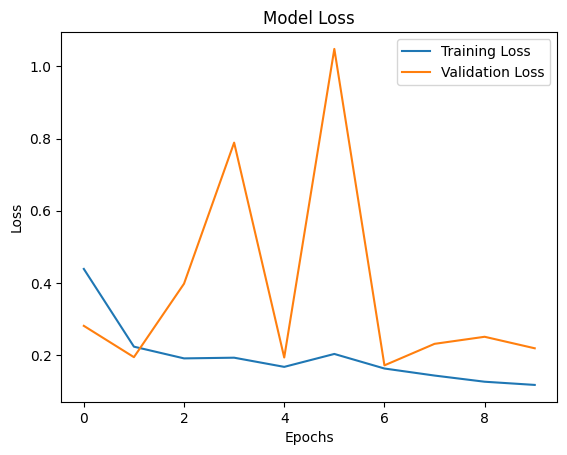

In [35]:
plt.plot(History.history['loss'], label='Training Loss') 
plt.plot(History.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend() # Needs to be in a list
plt.show()

# Model Evaluation and Testing

In [36]:
test_dataset

<_MapDataset element_spec=(TensorSpec(shape=(224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [37]:
test_dataset = test_dataset.batch(1) # Have to do this because we need to keep into account the dimension of the test dataset as well while evaluating.
lenet_model.evaluate(test_dataset)

# We have a 64.5% accuracy

5513/5513 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - accuracy: 0.9400 - loss: 0.2196


[0.21959078311920166, 0.9399601221084595]

In [38]:
def parasite_or_not(x):
    if (x < 0.5):
        return 'P'
    else:
        return 'U'

In [39]:
parasite_or_not(lenet_model.predict(test_dataset.take(1))[0][0]) 

'''# lenet_model.predict(test_dataset.take(1)) outputs:
[
  [0.85], # Image 0 prediction
  [0.12], # Image 1 prediction
  [0.44], # Image 2 prediction
  ...
  [0.91]  # Image 32 prediction
]
TensorFlow models output predictions in a 2D batch format [[0.85], [0.12]]. The first [0] selects the specific image in the batch, and the second [0] extracts the raw probability number 
from inside that vector.'''

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step


'# lenet_model.predict(test_dataset.take(1)) outputs:\n[\n  [0.85], # Image 0 prediction\n  [0.12], # Image 1 prediction\n  [0.44], # Image 2 prediction\n  ...\n  [0.91]  # Image 32 prediction\n]\nTensorFlow models output predictions in a 2D batch format [[0.85], [0.12]]. The first [0] selects the specific image in the batch, and the second [0] extracts the raw probability number \nfrom inside that vector.'

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 532ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


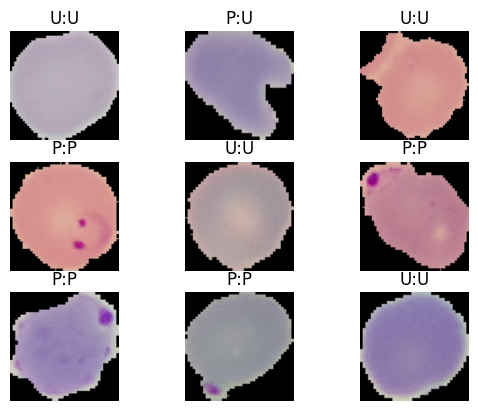

In [40]:
for i,(image,label) in enumerate(test_dataset.take(9)):

    ax = plt.subplot(3,3, i+1)
    plt.imshow(image[0])
    plt.title(str(parasite_or_not(label.numpy()[0])) + ':' + str(parasite_or_not(lenet_model.predict(image)[0][0])))
    plt.axis('off')

# Saving to and Loading from Google Drive

In [42]:
from google.colab import drive # type: ignore
drive.mount('/content/drive')

Mounted at /content/drive


In [43]:
lenet_model.export('/content/drive/MyDrive/lenet_saved_directory')
drive_folder_path = '/content/drive/MyDrive/lenet_saved_directory'

# Load the directory as a specialized inference layer
lenet_loaded = tf.keras.layers.TFSMLayer(drive_folder_path, call_endpoint='serve')

print("Model loaded successfully from Google Drive!")

Saved artifact at '/content/drive/MyDrive/lenet_saved_directory'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  138333883771280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138333883771664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138333883770896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138333883771472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138333883770128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138333883769744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138333883772816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138333883769552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138333883773776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138333883773968: TensorSpec(shape=(), dtype=tf.resource,

In [44]:
lenet_model.save('/content/drive/MyDrive/lenet_malaria_saved_model.keras')
lenet_loaded = tf.keras.models.load_model('/content/drive/MyDrive/lenet_malaria_saved_model.keras')
lenet_loaded.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 6)    │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 6)    │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 16)   │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 46656)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │     4,665,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,004,365 (53.42 MB)

 Trainable params: 4,668,033 (17.81 MB)

 Non-trainable params: 264 (1.03 KB)

 Optimizer params: 9,336,068 (35.61 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


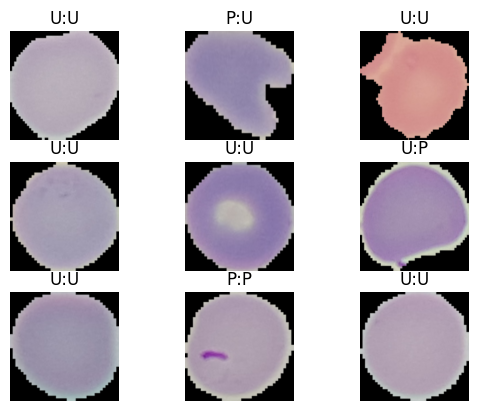

In [45]:
# Using the LOADED MODEL from google drive to do the predictions
for i,(image,label) in enumerate(test_dataset.take(9)):

    ax = plt.subplot(3,3, i+1)
    plt.imshow(image[0])
    plt.title(str(parasite_or_not(label.numpy()[0])) + ':' + str(parasite_or_not(lenet_loaded.predict(image)[0][0])))
    plt.axis('off')

In [46]:
lenet_loaded.evaluate(test_dataset)

5513/5513 ━━━━━━━━━━━━━━━━━━━━ 30s 4ms/step - accuracy: 0.9400 - loss: 0.2189


[0.21892894804477692, 0.9399601221084595]

# Saving using the HDF5 method -> lightweight Model Saving Method

In [47]:
# In a HDF5 format the configurations aren't stored, so you will have to compile the model again
lenet_model.save('/content/drive/MyDrive/lenet_malaria_model.h5')


In [48]:
h5_model_path = '/content/drive/MyDrive/lenet_malaria_model.h5'
lenet_loaded_h5 = tf.keras.models.load_model(h5_model_path, compile=False) 
# If you only want to use the model for inference (making predictions) 
#and want to skip loading the optimizer, you can add compile=False to speed things up
# Setting compile=False tells Keras: "Just load the brain (weights and architecture). Do not waste time loading the training setup or rebuilding the optimizer."
lenet_loaded_h5.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 6)    │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 6)    │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 16)   │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 46656)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │     4,665,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,668,297 (17.81 MB)

 Trainable params: 4,668,033 (17.81 MB)

 Non-trainable params: 264 (1.03 KB)

In [53]:
# lenet_loaded_h5.evaluate(test_dataset) # In a HDF5 format the configurations aren't stored, so you will have to compile the model again

# ERROR GIVEN - You must call `compile()` before using the model.

#### Saving Just the Weights given that we already have the model's configurations

In [54]:
# lenet_model.save_weights("weights/lenet_weights.weights.h5")

In [52]:
# lenet_weights_model = lenet_model.load_weights("weights/lenet_weights")